##Setup and Data Download
This initial cell remains the same. It sets up the environment, downloads the dataset, and sets a random seed for reproducibility.

In [6]:
import torch
import os
import random
import numpy as np

# Set a fixed random seed for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# === DIRECT KAGGLE CREDENTIALS ===
os.environ['KAGGLE_USERNAME'] = 'asd147'
os.environ['KAGGLE_KEY']     = '6a95e405001115800e2e18044513a965'
# ===================================


# Always download (kaggle will overwrite the zip if it exists)
!kaggle datasets download -d andrewmvd/car-plate-detection


# Force-overwrite when unzipping (-o = overwrite without prompt)
!unzip -q -o car-plate-detection.zip -d ./data


## Clean up
!rm -f car-plate-detection.zip

# Check for GPU availability and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/car-plate-detection
License(s): CC0-1.0
100% 203M/203M [00:05<00:00, 39.4MB/s]

Using device: cuda


##Dataset and Dataloader (Modified for Faster R-CNN)
The PlateDataset is updated to return targets in the dictionary format required by Faster R-CNN. The training transformations are also made more aggressive.

In [7]:
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

class PlateDetectionDataset(Dataset):
    def __init__(self, data_dir, image_files, width, height, transforms=None):
        self.transforms = transforms
        self.data_dir = data_dir
        self.height = height
        self.width = width
        self.image_files = image_files

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.data_dir, 'images', img_name)

        # Load image
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.width, self.height), resample=Image.BILINEAR)

        # Load annotation
        ann_name = img_name.replace('.png', '.xml')
        ann_path = os.path.join(self.data_dir, 'annotations', ann_name)
        tree = ET.parse(ann_path)
        root = tree.getroot()

        # Get original image size for scaling
        orig_w = int(root.find('size').find('width').text)
        orig_h = int(root.find('size').find('height').text)

        bndbox = root.find('object').find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        # Scale the bounding box
        xmin_corr = (xmin / orig_w) * self.width
        xmax_corr = (xmax / orig_w) * self.width
        ymin_corr = (ymin / orig_h) * self.height
        ymax_corr = (ymax / orig_h) * self.height

        boxes = torch.as_tensor([[xmin_corr, ymin_corr, xmax_corr, ymax_corr]], dtype=torch.float32)

        # There is only one class: license plate (plus background)
        labels = torch.ones((1,), dtype=torch.int64) # 1 for license plate

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.image_files)

# Define more aggressive transformations for training
def get_transform(train):
    transforms = []
    transforms.append(T.ToTensor())
    if train:
        # These augmentations are applied to the tensor image
        transforms.append(T.RandomPerspective(distortion_scale=0.3, p=0.5))
        transforms.append(T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1))
    # Normalize after other tensor-based transforms
    transforms.append(T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]))
    return T.Compose(transforms)

# Collate function to handle different numbers of objects in images (for future use)
def collate_fn(batch):
    return tuple(zip(*batch))

##Splitting Data and Creating DataLoaders (Modified)
We create the new dataset and dataloaders, making sure to use the collate_fn which is required for PyTorch's object detection models.

In [8]:
from sklearn.model_selection import train_test_split

IMG_WIDTH, IMG_HEIGHT = 480, 480 # Using a slightly larger image size
data_dir = './data'

all_image_files = sorted([f for f in os.listdir(os.path.join(data_dir, 'images')) if f.endswith('.png')])
train_files, val_files = train_test_split(all_image_files, test_size=0.2, random_state=42)

# Create dataset instances
train_dataset = PlateDetectionDataset(data_dir, train_files, IMG_WIDTH, IMG_HEIGHT, get_transform(train=True))
val_dataset = PlateDetectionDataset(data_dir, val_files, IMG_WIDTH, IMG_HEIGHT, get_transform(train=False))

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

Training set size: 346
Validation set size: 87


##Model Architecture: Fine-Tuning Faster R-CNN (New)
Here we define the state-of-the-art Faster R-CNN model. We load the pre-trained version and replace the final "box predictor" layer to fit our single-class problem (license plate).

In [9]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def create_detection_model():
    # Load a model pre-trained on COCO
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one
    # num_classes includes the background, so 2 classes (background + license_plate)
    num_classes = 2
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = create_detection_model()
model = model.to(device)

# Print the number of trainable parameters
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 168MB/s]


##Training Loop for Faster R-CNN (New)
The training loop for this model is different. The model itself calculates the loss when you pass it images and targets.

In [10]:
from tqdm import tqdm

num_epochs = 15 # This model learns faster, so we need fewer epochs
best_val_iou = 0.0

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    # Training
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_train_loss += losses.item()

    avg_train_loss = total_train_loss / len(train_loader)
    lr_scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")
    # We will evaluate IoU directly in the next step instead of validation loss
    # as the model returns multiple loss components.

print("\nFinished Training. Now evaluating the final model.")

Epoch 1/15 [Train]: 100%|██████████| 44/44 [01:42<00:00,  2.33s/it]


Epoch 1/15, Train Loss: 0.2291


Epoch 2/15 [Train]: 100%|██████████| 44/44 [01:44<00:00,  2.37s/it]


Epoch 2/15, Train Loss: 0.1530


Epoch 3/15 [Train]: 100%|██████████| 44/44 [01:43<00:00,  2.35s/it]


...

Epoch 13/15, Train Loss: 0.1309


Epoch 14/15 [Train]: 100%|██████████| 44/44 [01:43<00:00,  2.35s/it]


Epoch 14/15, Train Loss: 0.1229


Epoch 15/15 [Train]: 100%|██████████| 44/44 [01:44<00:00,  2.38s/it]

Epoch 15/15, Train Loss: 0.1222

Finished Training. Now evaluating the final model.


##Performance Evaluation with IoU (Modified)
We need a new evaluation function because the model output format is different now. It gives a dictionary with boxes, labels, and scores.

In [11]:
# Function from TorchVision references to calculate IoU for object detection
def calculate_iou_detection(pred_boxes, true_boxes):
    # box format: [xmin, ymin, xmax, ymax]

    if pred_boxes.shape[0] == 0 or true_boxes.shape[0] == 0:
        return torch.tensor(0.0)

    # Ensure boxes are [N, 4] and [M, 4]
    pred_boxes = pred_boxes.view(-1, 4)
    true_boxes = true_boxes.view(-1, 4)

    # Calculate intersection coordinates
    inter_xmin = torch.max(pred_boxes[:, 0].unsqueeze(1), true_boxes[:, 0])
    inter_ymin = torch.max(pred_boxes[:, 1].unsqueeze(1), true_boxes[:, 1])
    inter_xmax = torch.min(pred_boxes[:, 2].unsqueeze(1), true_boxes[:, 2])
    inter_ymax = torch.min(pred_boxes[:, 3].unsqueeze(1), true_boxes[:, 3])

    inter_area = torch.clamp(inter_xmax - inter_xmin, min=0) * torch.clamp(inter_ymax - inter_ymin, min=0)

    # Calculate union area
    pred_area = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
    true_area = (true_boxes[:, 2] - true_boxes[:, 0]) * (true_boxes[:, 3] - true_boxes[:, 1])
    union_area = pred_area.unsqueeze(1) + true_area - inter_area

    iou = inter_area / (union_area + 1e-6)

    # Return the max IoU for each prediction
    return iou.max(dim=1)[0]


# Evaluate the model on the validation set
model.eval()
total_iou = 0.0
total_images = 0

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = list(img.to(device) for img in images)
        outputs = model(images)

        for i, output in enumerate(outputs):
            pred_boxes = output['boxes']
            true_boxes = targets[i]['boxes'].to(device)

            # We only care about the prediction with the highest score
            if len(pred_boxes) > 0:
                best_pred_box = pred_boxes[0].unsqueeze(0) # Get the most confident prediction
                iou_score = calculate_iou_detection(best_pred_box, true_boxes)
                total_iou += iou_score.sum().item()

        total_images += len(images)

avg_iou = total_iou / total_images
print(f"\nAverage Intersection over Union (IoU) on the validation set: {avg_iou:.4f}")

Evaluating: 100%|██████████| 11/11 [00:09<00:00,  1.12it/s]


Average Intersection over Union (IoU) on the validation set: 0.7469


##Visualizing Predictions (Modified)
The visualization function is updated to handle the new model's output format.

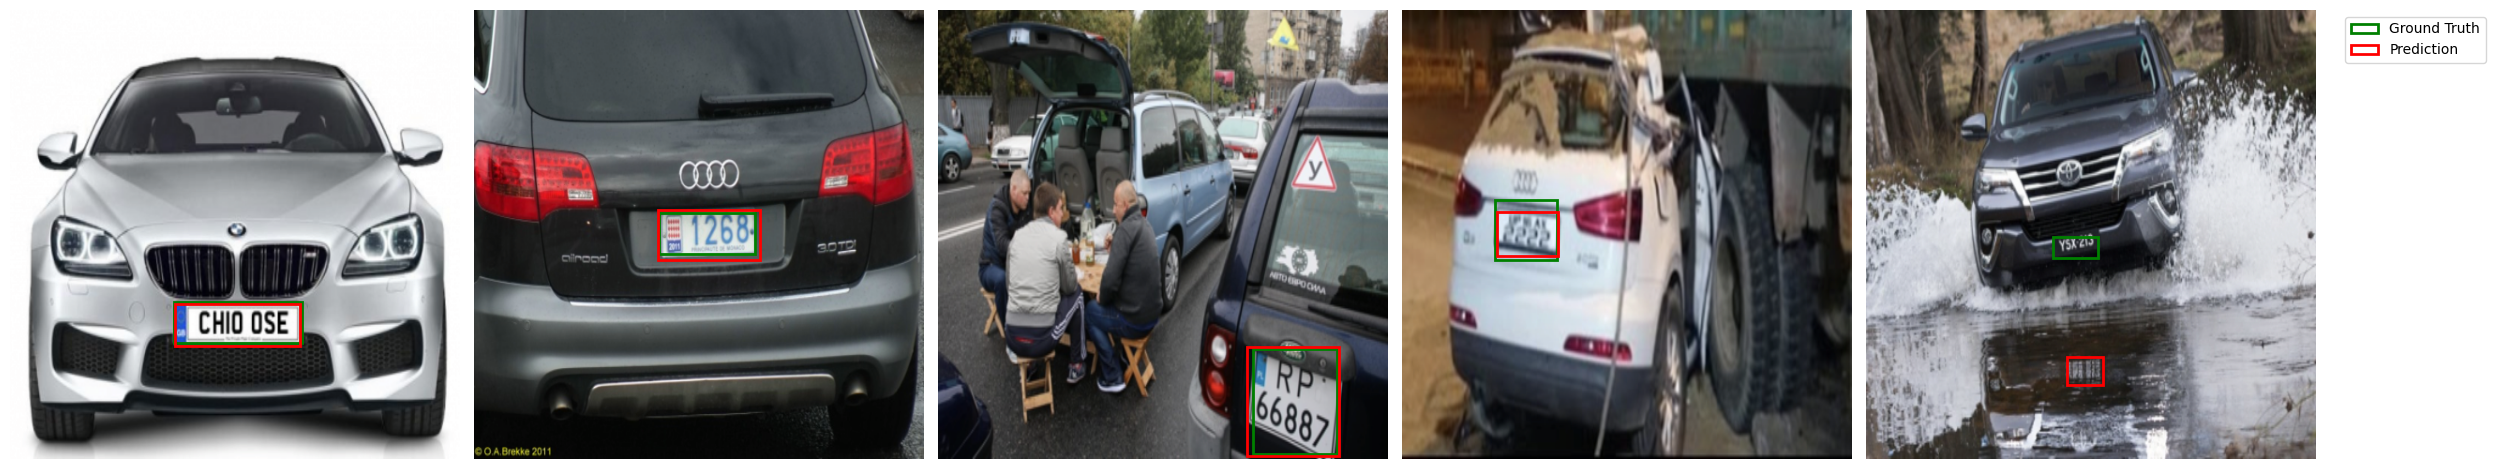

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_detection_predictions(dataset, model, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(25, 5))
    indices = random.sample(range(len(dataset)), num_samples)

    model.eval()
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, target = dataset[idx]

            # Un-normalize for visualization
            inv_normalize = T.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            img_vis = inv_normalize(img)
            img_vis = T.ToPILImage()(img_vis)

            # Get prediction
            prediction = model([img.to(device)])[0]

            ax = axes[i]
            ax.imshow(img_vis)
            ax.axis('off')

            # Draw ground-truth box (Green)
            true_box = target['boxes'][0]
            xmin, ymin, xmax, ymax = true_box
            gt_rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
            ax.add_patch(gt_rect)

            # Draw predicted box (Red) if any prediction exists
            if len(prediction['boxes']) > 0:
                # Use the prediction with the highest score
                best_pred_box = prediction['boxes'][0]
                xmin, ymin, xmax, ymax = best_pred_box.cpu()
                pred_rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
                ax.add_patch(pred_rect)

    plt.legend(handles=[gt_rect, pred_rect], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Visualize predictions on the validation set
visualize_detection_predictions(val_dataset, model)